<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/03_model_training/phase3_unet_full_curated_using_previous_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: U-Net Training — Segmentation-Only & Multi-Task (Full Curated Dataset, Resumed from Phase 2 Checkpoint)

## Overview
Trains two complementary U-Net pipelines on **all curated clean tiles** (no stable/sparse split),
then compares their building-count estimates against Microsoft Building Footprints.

> **Goal:** Building count prediction. Segmentation is a means to an end.

> **Note:** Both Part A and Part B resume from the best checkpoint trained on the smaller Phase 2 dataset, rather than training from scratch. This allows the model to leverage previously learned features and improve further with the full curated dataset.

## Prerequisites
- Phase 1 & 2 completed. Google Drive must contain:
  - `tiles/images/`, `tiles/masks/`
  - `metadata/tile_metadata.csv` — includes corrected `footprint_count` and `clean` flag
  - `metadata/train_ids.csv`, `metadata/val_ids.csv`
  - `checkpoints/unet_seg_best_full_curated.pt` — Phase 2 best seg checkpoint
  - `checkpoints/unet_multitask_best_full_curated.pt` — Phase 2 best multitask checkpoint

## Notebook Structure
| Section | Description |
|---------|-------------|
| **0. Setup** | Install, import, mount Drive |
| **0-2. Config** | Paths, hyperparameters |
| **0-3. Load Data** | All clean tiles from tile_metadata; train/val split |
| **Part A** | Seg-Only U-Net (ResNet34, BCE+Dice, metric=IoU) |
| **Part B** | MultiTask U-Net (shared encoder + count head, metric=IoU+MAE) |
| **Part C** | Count comparison: CC vs count head (MAE & Pearson r) |
| **Part D** | Summary visualizations |
| **Part E** | Experiment log |

## Key Hyperparameters
| Parameter | Value | Note |
|-----------|-------|------|
| Epochs | 30 | |
| Batch size | 4 | |
| LR | 1e-4 | AdamW, weight_decay=1e-4 |
| Scheduler | CosineAnnealingLR | eta_min=1e-6 |
| BCE / Dice weight | 0.5 / 0.5 | to be tuned in Phase 4 |
| SEG_W / COUNT_W | 1.0 / 0.5 | multitask total loss balance |
| Threshold | 0.5 | to be swept in Phase 4-1 |
| Min area | 50 px | to be swept in Phase 4-1 |

## 0. Installation

In [ ]:
import importlib
if importlib.util.find_spec('segmentation_models_pytorch') is None:
    !pip install segmentation-models-pytorch albumentations -q
if importlib.util.find_spec('cv2') is None:
    !pip install opencv-python-headless scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00


## 0-1. Import

In [ ]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from skimage import measure

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


## 0-2. Path & Hyperparameter Configuration

In [ ]:
import os
print(os.path.exists(META_DIR))
print(os.path.exists(f'{META_DIR}/tile_metadata.csv'))

False
False


In [ ]:
import subprocess, os

BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
DRIVE_IMG_DIR = f'{BASE_DIR}/tiles/images'
DRIVE_MSK_DIR = f'{BASE_DIR}/tiles/masks'

FAST_IMG_DIR  = '/content/fast_tiles/images'
FAST_MASK_DIR = '/content/fast_tiles/masks'

os.makedirs(FAST_IMG_DIR,  exist_ok=True)
os.makedirs(FAST_MASK_DIR, exist_ok=True)

print("Copying tiles to local SSD... (5~10 min)")
subprocess.run(['rsync', '-a', '--ignore-existing', f'{DRIVE_IMG_DIR}/', f'{FAST_IMG_DIR}/'])
subprocess.run(['rsync', '-a', '--ignore-existing', f'{DRIVE_MSK_DIR}/', f'{FAST_MASK_DIR}/'])
print("Done!")

# ── Update paths to local SSD ──────────────────────────────
TILE_IMG_DIR  = FAST_IMG_DIR
TILE_MASK_DIR = FAST_MASK_DIR
META_DIR      = f'{BASE_DIR}/metadata'
CKPT_DIR      = f'{BASE_DIR}/checkpoints'
OUT_DIR       = f'{BASE_DIR}/results_full_7462'

for d in [CKPT_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

BATCH_SIZE = 4
EPOCHS     = 30
LR         = 1e-4

BCE_W   = 0.5
DICE_W  = 0.5
SEG_W   = 1.0
COUNT_W = 0.5

THRESHOLD = 0.5
MIN_AREA  = 50

print(f'Seg loss   : {BCE_W} BCE + {DICE_W} Dice')
print(f'Total loss : {SEG_W}*seg + {COUNT_W}*count_mse')
print(f'Threshold  : {THRESHOLD} | Min area: {MIN_AREA} px')
print(f'Output dir : {OUT_DIR}')

Copying tiles to local SSD... (5~10 min)
Done!
Seg loss   : 0.5 BCE + 0.5 Dice
Total loss : 1.0*seg + 0.5*count_mse
Threshold  : 0.5 | Min area: 50 px
Output dir : /content/drive/MyDrive/michigan_unet_project/results_full_7462


## 0-3. Load Phase 1 & 2 Outputs

Load **all clean tiles** directly from `tile_metadata.csv`.
No curated CSV files needed — the `clean` flag from Phase 2 QC is the only filter.
`footprint_count` already includes the County 161 (Washtenaw) bug fix.

In [ ]:
df_meta = pd.read_csv(f'{META_DIR}/tile_metadata.csv',
                      dtype={'geoid': str, 'tract_id': str})
df_meta['footprint_count']     = df_meta['footprint_count'].fillna(0).astype(float)
df_meta['mask_building_ratio'] = df_meta['mask_building_ratio'].fillna(0).astype(float)

fp_count_map = df_meta.set_index('tile_id')['footprint_count'].to_dict()
ratio_map    = df_meta.set_index('tile_id')['mask_building_ratio'].to_dict()

# ── Load all Pre-Phase 3 QC-passed tiles ─────────────────────────────────
CURATED_DIR  = f'{BASE_DIR}/curated'
stats_csv    = f'{CURATED_DIR}/tile_stats_clean.csv'
all_tile_ids = pd.read_csv(stats_csv)['tile_id'].astype(str).tolist()
print(f'Pre-Phase 3 QC-passed tiles: {len(all_tile_ids)}')

# ── 80/20 random split on all 7,462 tiles ────────────────────────────────
random.seed(42)
shuffled = all_tile_ids.copy()
random.shuffle(shuffled)
n         = int(len(shuffled) * 0.8)
train_ids = shuffled[:n]
val_ids   = shuffled[n:]

mr = float(np.mean([ratio_map.get(t, 0) for t in train_ids]))
print(f'\nTrain : {len(train_ids)} | Val : {len(val_ids)}')
print(f'Train mean building_ratio  : {mr:.5f}')
print(f'Train mean footprint_count : {np.mean([fp_count_map.get(t,0) for t in train_ids]):.2f}')
print(f'Val   mean footprint_count : {np.mean([fp_count_map.get(t,0) for t in val_ids]):.2f}')

Pre-Phase 3 QC-passed tiles: 7462

Train : 5969 | Val : 1493
Train mean building_ratio  : 0.01935
Train mean footprint_count : 6.62
Val   mean footprint_count : 7.10


In [ ]:
# Tier distribution in train/val
def classify_tier(ratio):
    if ratio >= 0.05:    return 'Dense'
    elif ratio >= 0.001: return 'Sparse'
    else:                return 'Empty'

train_tiers = [classify_tier(ratio_map.get(t, 0)) for t in train_ids]
val_tiers   = [classify_tier(ratio_map.get(t, 0)) for t in val_ids]

print('\n[Train Tier Distribution]')
print(pd.Series(train_tiers).value_counts().to_string())

print('\n[Val Tier Distribution]')
print(pd.Series(val_tiers).value_counts().to_string())


[Train Tier Distribution]
Empty     3227
Sparse    1975
Dense      767

[Val Tier Distribution]
Empty     782
Sparse    516
Dense     195


## 0-4. Shared Dataset & Augmentation

`BuildingDataset` always returns `(img, mask, count_label)`.
- Seg-only training ignores `count_label`.
- `count_label = log1p(footprint_count)` — reduces skew; invert with `expm1` for evaluation.

In [ ]:
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_aug = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


class BuildingDataset(Dataset):
    def __init__(self, tile_ids, img_dir, mask_dir, fp_count_map, transform=None):
        self.tile_ids = tile_ids; self.img_dir = img_dir
        self.mask_dir = mask_dir; self.fp_count_map = fp_count_map
        self.transform = transform

    def __len__(self): return len(self.tile_ids)

    def __getitem__(self, idx):
        tid  = self.tile_ids[idx]
        img  = np.array(Image.open(f'{self.img_dir}/{tid}.png').convert('RGB'))
        mask = np.array(Image.open(f'{self.mask_dir}/{tid}.png').convert('L'))
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']; mask = aug['mask'].unsqueeze(0)
        count_label = torch.tensor(np.log1p(float(self.fp_count_map.get(tid, 0))),
                                   dtype=torch.float32)
        return img, mask, count_label


def make_loaders(t_ids, v_ids):
    t_ds = BuildingDataset(t_ids, TILE_IMG_DIR, TILE_MASK_DIR, fp_count_map, train_aug)
    v_ds = BuildingDataset(v_ids, TILE_IMG_DIR, TILE_MASK_DIR, fp_count_map, val_aug)
    t_ld = DataLoader(t_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    v_ld = DataLoader(v_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f'Train: {len(t_ds)} | Val: {len(v_ds)}')
    return t_ld, v_ld

## 0-5. Shared Loss & Metric Functions

In [ ]:
def dice_loss(pred, target, smooth=1.):
    pred = torch.sigmoid(pred).view(-1); target = target.view(-1)
    inter = (pred * target).sum()
    return 1 - (2. * inter + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, thresh=THRESHOLD):
    pred  = (torch.sigmoid(pred) > thresh).float()
    inter = (pred * target).sum()
    union = (pred + target).clamp(0, 1).sum()
    return (inter / (union + 1e-6)).item()

def count_mae(pred_log, target_log):
    return (torch.expm1(pred_log.clamp(min=0)) -
            torch.expm1(target_log.clamp(min=0))).abs().mean().item()

---
# Part A — Segmentation-Only U-Net

Standard `smp.Unet` with ResNet34 encoder.
Loss = `BCE_W * BCE(pos-weighted) + DICE_W * Dice`. Metric = **IoU**.

## A-1. Model

In [ ]:
def build_seg_model():
    m = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet',
                 in_channels=3, classes=1, activation=None).to(DEVICE)
    print(f'Seg-only U-Net | params: {sum(p.numel() for p in m.parameters()):,}')
    return m

## A-2. Training

In [ ]:
def train_seg_model(train_loader, val_loader, ckpt_suffix='full_curated',
                    resume_ckpt=None):
    model = build_seg_model()

    # ── Resume from best checkpoint ──────────────────────────────────────
    if resume_ckpt is None:
        resume_ckpt = f'{CKPT_DIR}/unet_seg_best_{ckpt_suffix}.pt'
    if os.path.exists(resume_ckpt):
        model.load_state_dict(torch.load(resume_ckpt, map_location=DEVICE))
        print(f'[Resume] Loaded seg checkpoint: {resume_ckpt}')
    else:
        print(f'[Resume] No checkpoint found at {resume_ckpt} — training from scratch')
    # ─────────────────────────────────────────────────────────────────────

    mr    = float(np.mean([ratio_map.get(t, 0) for t in train_ids]))
    pw    = torch.tensor([(1 - mr) / (mr + 1e-6)]).to(DEVICE).clamp(1.0, 20.0)
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    print(f'pos_weight: {pw.item():.2f}')

    def seg_loss(p, t):
        return BCE_W * bce_fn(p, t) + DICE_W * dice_loss(p, t)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    history  = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    best_iou = 0.0
    ckpt_name = f'unet_seg_best_{ckpt_suffix}.pt'

    for epoch in range(1, EPOCHS + 1):
        model.train(); t_loss = 0
        for imgs, masks, _ in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = seg_loss(model(imgs), masks)
            loss.backward(); optimizer.step()
            t_loss += loss.item()

        model.eval(); v_loss = v_iou = 0
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds   = model(imgs)
                v_loss += seg_loss(preds, masks).item()
                v_iou  += iou_score(preds, masks)

        t_avg = t_loss/len(train_loader); v_avg = v_loss/len(val_loader)
        i_avg = v_iou/len(val_loader); scheduler.step()
        history['train_loss'].append(t_avg)
        history['val_loss'].append(v_avg)
        history['val_iou'].append(i_avg)
        print(f'Epoch {epoch:02d}/{EPOCHS} | Train: {t_avg:.4f} | Val: {v_avg:.4f} | IoU: {i_avg:.4f}')

        if i_avg > best_iou:
            best_iou = i_avg
            torch.save(model.state_dict(), f'{CKPT_DIR}/{ckpt_name}')
            print(f'  -> Best saved (IoU: {best_iou:.4f})')

    print(f'\nDone! Best Val IoU: {best_iou:.4f}')
    return model, history, best_iou, ckpt_name


train_loader, val_loader = make_loaders(train_ids, val_ids)
seg_model, hist_seg, best_iou_seg, ckpt_seg = train_seg_model(train_loader, val_loader)

Train: 5969 | Val: 1493


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Seg-only U-Net | params: 24,436,369
[Resume] Loaded seg checkpoint: /content/drive/MyDrive/michigan_unet_project/checkpoints/unet_seg_best_full_curated.pt
pos_weight: 20.00
Epoch 01/30 | Train: 0.3449 | Val: 0.3003 | IoU: 0.5110
  -> Best saved (IoU: 0.5110)
Epoch 02/30 | Train: 0.3300 | Val: 0.2931 | IoU: 0.5230
  -> Best saved (IoU: 0.5230)
Epoch 03/30 | Train: 0.3312 | Val: 0.2976 | IoU: 0.5006
Epoch 04/30 | Train: 0.3260 | Val: 0.2897 | IoU: 0.4998
Epoch 05/30 | Train: 0.3217 | Val: 0.2860 | IoU: 0.5296
  -> Best saved (IoU: 0.5296)
Epoch 06/30 | Train: 0.3136 | Val: 0.2980 | IoU: 0.5205
Epoch 07/30 | Train: 0.3075 | Val: 0.2880 | IoU: 0.5069
Epoch 08/30 | Train: 0.3194 | Val: 0.2995 | IoU: 0.5032
Epoch 09/30 | Train: 0.3077 | Val: 0.2983 | IoU: 0.5198
Epoch 10/30 | Train: 0.3016 | Val: 0.2895 | IoU: 0.5411
  -> Best saved (IoU: 0.5411)
Epoch 11/30 | Train: 0.2966 | Val: 0.2911 | IoU: 0.5212
Epoch 12/30 | Train: 0.2966 | Val: 0.2955 | IoU: 0.4683
Epoch 13/30 | Train: 0.2931 | Val: 

## A-3. Visualization

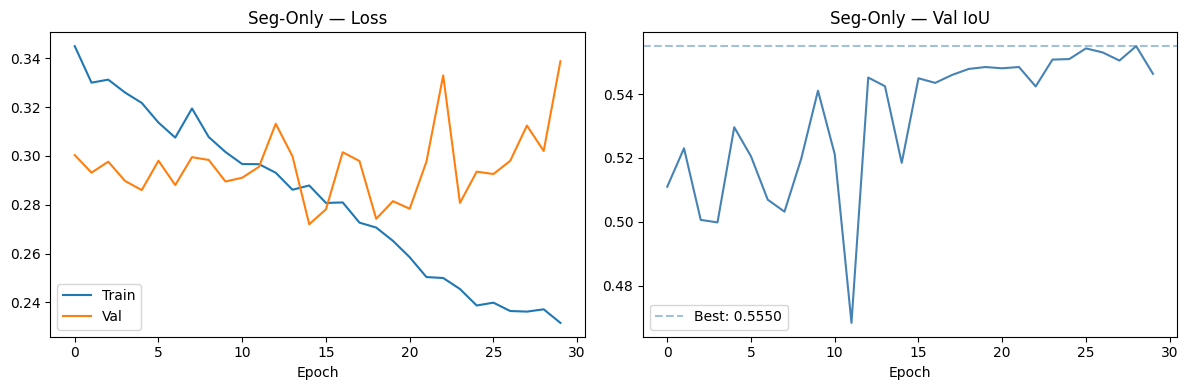

Best Val IoU: 0.5550


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_seg['train_loss'], label='Train')
axes[0].plot(hist_seg['val_loss'],   label='Val')
axes[0].set_title('Seg-Only — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(hist_seg['val_iou'], color='steelblue')
axes[1].axhline(best_iou_seg, color='steelblue', linestyle='--', alpha=0.5,
                label=f'Best: {best_iou_seg:.4f}')
axes[1].set_title('Seg-Only — Val IoU'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_a_seg_only_curves.png', dpi=150)
plt.show()
print(f'Best Val IoU: {best_iou_seg:.4f}')

---
# Part B — Multi-Task U-Net

Shared ResNet34 encoder + two heads:
- **Seg head**: U-Net decoder → `(B, 1, H, W)` logits
- **Count head**: bottleneck GAP → FC(512→128→1) → scalar (log1p space)

Loss = `SEG_W*(BCE+Dice) + COUNT_W*MSE(log1p)`. Best checkpoint by **val IoU**.

## B-1. MultiTaskUNet Definition

In [ ]:
class MultiTaskUNet(nn.Module):
    def __init__(self, encoder_name='resnet34', encoder_weights='imagenet'):
        super().__init__()
        self.unet = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                             in_channels=3, classes=1, activation=None)
        bdim = self.unet.encoder.out_channels[-1]  # resnet34 -> 512
        self.count_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(bdim, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(128, 1),
        )

    def forward(self, x):
        features    = self.unet.encoder(x)
        decoder_out = self.unet.decoder(features)
        seg_logit   = self.unet.segmentation_head(decoder_out)  # (B,1,H,W)
        count_pred  = self.count_head(features[-1]).squeeze(1)  # (B,)
        return seg_logit, count_pred


def build_multitask_model():
    m = MultiTaskUNet().to(DEVICE)
    print(f'MultiTaskUNet | params: {sum(p.numel() for p in m.parameters()):,} '
          f'| count head: {sum(p.numel() for p in m.count_head.parameters()):,}')
    return m

## B-2. Training

In [ ]:
def train_multitask_model(train_loader, val_loader, ckpt_suffix='full_curated',
                         resume_ckpt=None):
    model  = build_multitask_model()

    # ── Resume from best checkpoint ──────────────────────────────────────
    if resume_ckpt is None:
        resume_ckpt = f'{CKPT_DIR}/unet_multitask_best_{ckpt_suffix}.pt'
    if os.path.exists(resume_ckpt):
        model.load_state_dict(torch.load(resume_ckpt, map_location=DEVICE))
        print(f'[Resume] Loaded multitask checkpoint: {resume_ckpt}')
    else:
        print(f'[Resume] No checkpoint found at {resume_ckpt} — training from scratch')
    # ─────────────────────────────────────────────────────────────────────

    mr     = float(np.mean([ratio_map.get(t, 0) for t in train_ids]))
    pw     = torch.tensor([(1 - mr) / (mr + 1e-6)]).to(DEVICE).clamp(1.0, 20.0)
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    mse_fn = nn.MSELoss()
    print(f'pos_weight: {pw.item():.2f}')

    def combined_loss(sp, st, cp, ct):
        ls = BCE_W * bce_fn(sp, st) + DICE_W * dice_loss(sp, st)
        lc = mse_fn(cp, ct)
        return SEG_W * ls + COUNT_W * lc, ls, lc

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    history = {'train_loss': [], 'train_seg_loss': [], 'train_count_loss': [],
               'val_loss':   [], 'val_seg_loss':   [], 'val_count_loss':   [],
               'val_iou': [], 'val_mae': []}
    best_iou  = 0.0
    ckpt_name = f'unet_multitask_best_{ckpt_suffix}.pt'

    for epoch in range(1, EPOCHS + 1):
        model.train(); t_loss = t_seg = t_cnt = 0
        for imgs, masks, counts in train_loader:
            imgs, masks, counts = imgs.to(DEVICE), masks.to(DEVICE), counts.to(DEVICE)
            optimizer.zero_grad()
            sp, cp = model(imgs)
            loss, ls, lc = combined_loss(sp, masks, cp, counts)
            loss.backward(); optimizer.step()
            t_loss += loss.item(); t_seg += ls.item(); t_cnt += lc.item()

        model.eval(); v_loss = v_seg = v_cnt = v_iou = v_mae = 0
        with torch.no_grad():
            for imgs, masks, counts in val_loader:
                imgs, masks, counts = imgs.to(DEVICE), masks.to(DEVICE), counts.to(DEVICE)
                sp, cp = model(imgs)
                loss, ls, lc = combined_loss(sp, masks, cp, counts)
                v_loss += loss.item(); v_seg += ls.item(); v_cnt += lc.item()
                v_iou  += iou_score(sp, masks)
                v_mae  += count_mae(cp, counts)

        n_tr = len(train_loader); n_vl = len(val_loader)
        t_avg = t_loss/n_tr; t_s = t_seg/n_tr; t_c = t_cnt/n_tr
        v_avg = v_loss/n_vl; v_s = v_seg/n_vl; v_c = v_cnt/n_vl
        i_avg = v_iou/n_vl;  m_avg = v_mae/n_vl
        scheduler.step()

        for k, v in zip(
            ['train_loss','train_seg_loss','train_count_loss',
             'val_loss','val_seg_loss','val_count_loss','val_iou','val_mae'],
            [t_avg, t_s, t_c, v_avg, v_s, v_c, i_avg, m_avg]
        ):
            history[k].append(v)

        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train {t_avg:.4f} (seg={t_s:.4f} cnt={t_c:.4f}) | '
              f'Val {v_avg:.4f} | IoU: {i_avg:.4f} | MAE: {m_avg:.2f}')

        if i_avg > best_iou:
            best_iou = i_avg
            torch.save(model.state_dict(), f'{CKPT_DIR}/{ckpt_name}')
            print(f'  -> Best saved (IoU: {best_iou:.4f})')

    print(f'\nDone! Best Val IoU: {best_iou:.4f} | Final Val MAE: {m_avg:.2f}')
    return model, history, best_iou, m_avg, ckpt_name


mt_model, hist_mt, best_iou_mt, final_mae_mt, ckpt_mt =     train_multitask_model(train_loader, val_loader)

MultiTaskUNet | params: 24,502,162 | count head: 65,793
[Resume] No checkpoint found at /content/drive/MyDrive/michigan_unet_project/checkpoints/unet_multitask_best_full_curated.pt — training from scratch
pos_weight: 20.00
Epoch 01/30 | Train 0.8642 (seg=0.6290 cnt=0.4703) | Val 2.3225 | IoU: 0.3027 | MAE: 462753.56
  -> Best saved (IoU: 0.3027)
Epoch 02/30 | Train 0.6104 (seg=0.4759 cnt=0.2691) | Val 0.5404 | IoU: 0.4103 | MAE: 55.30
  -> Best saved (IoU: 0.4103)
Epoch 03/30 | Train 0.5492 (seg=0.4223 cnt=0.2536) | Val 0.8696 | IoU: 0.4578 | MAE: 528.05
  -> Best saved (IoU: 0.4578)
Epoch 04/30 | Train 0.5023 (seg=0.3944 cnt=0.2158) | Val 0.4161 | IoU: 0.4675 | MAE: 5.74
  -> Best saved (IoU: 0.4675)
Epoch 05/30 | Train 0.4813 (seg=0.3789 cnt=0.2048) | Val 0.4767 | IoU: 0.4563 | MAE: 11.52
Epoch 06/30 | Train 0.4575 (seg=0.3627 cnt=0.1896) | Val 0.5910 | IoU: 0.4991 | MAE: 274.57
  -> Best saved (IoU: 0.4991)
Epoch 07/30 | Train 0.4441 (seg=0.3578 cnt=0.1727) | Val 0.3909 | IoU: 0.487

Finding Best IOU is not good, we need to focus on MAE instead of IOU


In [ ]:
def train_multitask_model(train_loader, val_loader, ckpt_suffix='full_curated',
                         resume_ckpt=None):
    model  = build_multitask_model()

    # ── Resume from best checkpoint ──────────────────────────────────────
    if resume_ckpt is None:
        resume_ckpt = f'{CKPT_DIR}/unet_multitask_best_{ckpt_suffix}.pt'
    if os.path.exists(resume_ckpt):
        model.load_state_dict(torch.load(resume_ckpt, map_location=DEVICE))
        print(f'[Resume] Loaded multitask checkpoint: {resume_ckpt}')
    else:
        print(f'[Resume] No checkpoint found at {resume_ckpt} — training from scratch')
    # ─────────────────────────────────────────────────────────────────────

    mr     = float(np.mean([ratio_map.get(t, 0) for t in train_ids]))
    pw     = torch.tensor([(1 - mr) / (mr + 1e-6)]).to(DEVICE).clamp(1.0, 20.0)
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    mse_fn = nn.MSELoss()
    print(f'pos_weight: {pw.item():.2f}')

    def combined_loss(sp, st, cp, ct):
        ls = BCE_W * bce_fn(sp, st) + DICE_W * dice_loss(sp, st)
        lc = mse_fn(cp, ct)
        return SEG_W * ls + COUNT_W * lc, ls, lc

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    history = {'train_loss': [], 'train_seg_loss': [], 'train_count_loss': [],
               'val_loss':   [], 'val_seg_loss':   [], 'val_count_loss':   [],
               'val_iou': [], 'val_mae': []}
    best_iou  = 0.0
    best_mae  = float('inf')
    ckpt_iou_name = f'unet_multitask_best_iou_{ckpt_suffix}.pt'
    ckpt_mae_name = f'unet_multitask_best_mae_{ckpt_suffix}.pt'

    for epoch in range(1, EPOCHS + 1):
        model.train(); t_loss = t_seg = t_cnt = 0
        for imgs, masks, counts in train_loader:
            imgs, masks, counts = imgs.to(DEVICE), masks.to(DEVICE), counts.to(DEVICE)
            optimizer.zero_grad()
            sp, cp = model(imgs)
            loss, ls, lc = combined_loss(sp, masks, cp, counts)
            loss.backward(); optimizer.step()
            t_loss += loss.item(); t_seg += ls.item(); t_cnt += lc.item()

        model.eval(); v_loss = v_seg = v_cnt = v_iou = v_mae = 0
        with torch.no_grad():
            for imgs, masks, counts in val_loader:
                imgs, masks, counts = imgs.to(DEVICE), masks.to(DEVICE), counts.to(DEVICE)
                sp, cp = model(imgs)
                loss, ls, lc = combined_loss(sp, masks, cp, counts)
                v_loss += loss.item(); v_seg += ls.item(); v_cnt += lc.item()
                v_iou  += iou_score(sp, masks)
                v_mae  += count_mae(cp, counts)

        n_tr = len(train_loader); n_vl = len(val_loader)
        t_avg = t_loss/n_tr; t_s = t_seg/n_tr; t_c = t_cnt/n_tr
        v_avg = v_loss/n_vl; v_s = v_seg/n_vl; v_c = v_cnt/n_vl
        i_avg = v_iou/n_vl;  m_avg = v_mae/n_vl
        scheduler.step()

        for k, v in zip(
            ['train_loss','train_seg_loss','train_count_loss',
             'val_loss','val_seg_loss','val_count_loss','val_iou','val_mae'],
            [t_avg, t_s, t_c, v_avg, v_s, v_c, i_avg, m_avg]
        ):
            history[k].append(v)

        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train {t_avg:.4f} (seg={t_s:.4f} cnt={t_c:.4f}) | '
              f'Val {v_avg:.4f} | IoU: {i_avg:.4f} | MAE: {m_avg:.2f}')

        if i_avg > best_iou:
            best_iou = i_avg
            torch.save(model.state_dict(), f'{CKPT_DIR}/{ckpt_iou_name}')
            print(f'  -> IoU Best saved (IoU: {best_iou:.4f})')

        if m_avg < best_mae:
            best_mae = m_avg
            torch.save(model.state_dict(), f'{CKPT_DIR}/{ckpt_mae_name}')
            print(f'  -> MAE Best saved (MAE: {best_mae:.2f})')

    print(f'\nDone! Best Val IoU: {best_iou:.4f} | Best Val MAE: {best_mae:.2f}')
    return model, history, best_iou, best_mae, ckpt_mae_name


EPOCHS = 15
LR     = 3e-5
train_loader, val_loader = make_loaders(train_ids, val_ids)
mt_model, hist_mt, best_iou_mt, best_mae_mt, ckpt_mt = \
    train_multitask_model(train_loader, val_loader)

Train: 5969 | Val: 1493
MultiTaskUNet | params: 24,502,162 | count head: 65,793
[Resume] Loaded multitask checkpoint: /content/drive/MyDrive/michigan_unet_project/checkpoints/unet_multitask_best_full_curated.pt
pos_weight: 20.00
Epoch 01/15 | Train 0.3234 (seg=0.2725 cnt=0.1019) | Val 0.5325 | IoU: 0.5407 | MAE: 278.45
  -> IoU Best saved (IoU: 0.5407)
  -> MAE Best saved (MAE: 278.45)
Epoch 02/15 | Train 0.3233 (seg=0.2713 cnt=0.1040) | Val 1.1473 | IoU: 0.5484 | MAE: 14968.97
  -> IoU Best saved (IoU: 0.5484)
Epoch 03/15 | Train 0.3309 (seg=0.2809 cnt=0.0999) | Val 0.5910 | IoU: 0.5420 | MAE: 372.00
Epoch 04/15 | Train 0.3181 (seg=0.2654 cnt=0.1053) | Val 0.7360 | IoU: 0.5324 | MAE: 1630.44
Epoch 05/15 | Train 0.3092 (seg=0.2588 cnt=0.1009) | Val 0.6606 | IoU: 0.5440 | MAE: 739.83
Epoch 06/15 | Train 0.3020 (seg=0.2529 cnt=0.0984) | Val 1.1512 | IoU: 0.5474 | MAE: 22215.27
Epoch 07/15 | Train 0.2992 (seg=0.2504 cnt=0.0976) | Val 0.5744 | IoU: 0.5543 | MAE: 352.24
  -> IoU Best saved 

## B-3. Visualization

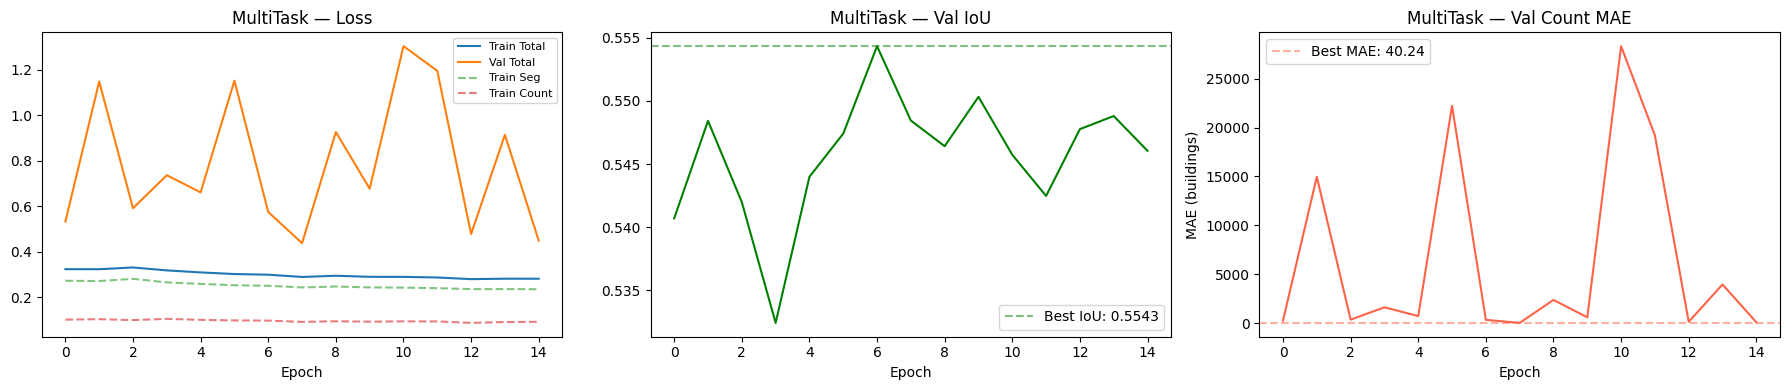

Best Val IoU: 0.5543 | Best Val MAE: 40.24


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist_mt['train_loss'],       label='Train Total')
axes[0].plot(hist_mt['val_loss'],         label='Val Total')
axes[0].plot(hist_mt['train_seg_loss'],   label='Train Seg',   linestyle='--', alpha=0.6)
axes[0].plot(hist_mt['train_count_loss'], label='Train Count', linestyle='--', alpha=0.6)
axes[0].set_title('MultiTask — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)

axes[1].plot(hist_mt['val_iou'], color='green')
axes[1].axhline(best_iou_mt, color='green', linestyle='--', alpha=0.5,
                label=f'Best IoU: {best_iou_mt:.4f}')
axes[1].set_title('MultiTask — Val IoU'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(hist_mt['val_mae'], color='tomato')
axes[2].axhline(best_mae_mt, color='tomato', linestyle='--', alpha=0.5,
                label=f'Best MAE: {best_mae_mt:.2f}')
axes[2].set_title('MultiTask — Val Count MAE')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE (buildings)')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_b_multitask_curves.png', dpi=150)
plt.show()
print(f'Best Val IoU: {best_iou_mt:.4f} | Best Val MAE: {best_mae_mt:.2f}')

---
# Part C — Building Count Comparison

| Method | Model | How count is derived |
|--------|-------|----------------------|
| **CC** | Seg-only U-Net | predicted mask → connected components (skimage) |
| **MT-head** | MultiTaskUNet | count head output (log1p → expm1) |

Metrics: **MAE** and **Pearson r** vs. `footprint_count`.

## C-1. Inference on Validation Set

In [ ]:
seg_eval = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                    in_channels=3, classes=1, activation=None).to(DEVICE)
seg_eval.load_state_dict(torch.load(f'{CKPT_DIR}/{ckpt_seg}', map_location=DEVICE))
seg_eval.eval()

mt_eval = MultiTaskUNet().to(DEVICE)
mt_eval.load_state_dict(torch.load(f'{CKPT_DIR}/{ckpt_mt}', map_location=DEVICE))
mt_eval.eval()

_, val_loader_eval = make_loaders(train_ids, val_ids)
gt_counts = []; cc_counts = []; mt_counts = []

with torch.no_grad():
    for imgs, masks, counts in val_loader_eval:
        imgs = imgs.to(DEVICE)

        # Seg-only -> CC count (with min area filter)
        seg_logit  = seg_eval(imgs)
        pred_masks = (torch.sigmoid(seg_logit) > THRESHOLD).cpu().numpy()
        for b in range(pred_masks.shape[0]):
            labeled = measure.label(pred_masks[b, 0])
            n_cc    = sum(1 for r in measure.regionprops(labeled) if r.area >= MIN_AREA)
            cc_counts.append(n_cc)

        # MultiTask count head
        _, cnt_pred = mt_eval(imgs)
        mt_counts.extend(torch.expm1(cnt_pred.clamp(min=0)).cpu().numpy().tolist())

        # Ground truth
        gt_counts.extend(torch.expm1(counts.clamp(min=0)).numpy().tolist())

gt_arr = np.array(gt_counts)
cc_arr = np.array(cc_counts, dtype=float)
mt_arr = np.array(mt_counts)

mae_cc  = np.abs(cc_arr - gt_arr).mean()
mae_mt  = np.abs(mt_arr - gt_arr).mean()
corr_cc = np.corrcoef(cc_arr, gt_arr)[0, 1]
corr_mt = np.corrcoef(mt_arr, gt_arr)[0, 1]

print('=' * 54)
print(f'  Method            |   MAE   | Pearson r')
print(f'  CC (seg-only)     | {mae_cc:6.2f}  | {corr_cc:.4f}')
print(f'  Count head (MT)   | {mae_mt:6.2f}  | {corr_mt:.4f}')
print('=' * 54)
print(f'Winner by MAE        : {"Count head" if mae_mt < mae_cc else "CC (seg-only)"}')
print(f'Winner by correlation: {"Count head" if corr_mt > corr_cc else "CC (seg-only)"}')

Train: 5969 | Val: 1493
  Method            |   MAE   | Pearson r
  CC (seg-only)     |   1.54  | 0.9568
  Count head (MT)   |  40.32  | 0.6264
Winner by MAE        : CC (seg-only)
Winner by correlation: CC (seg-only)


## C-2. Scatter Plots — Predicted vs Ground Truth

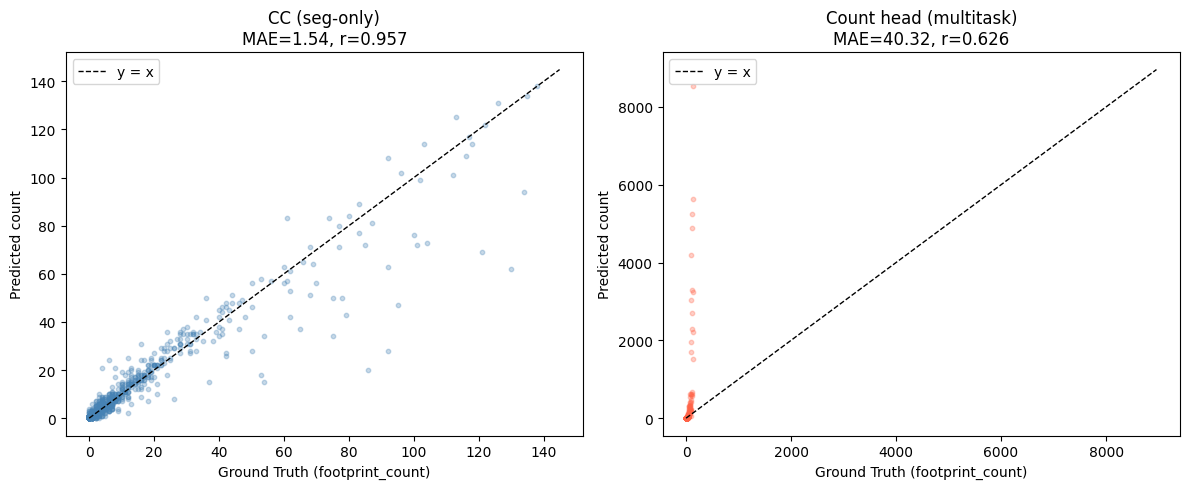

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label, color in [
    (axes[0], cc_arr, f'CC (seg-only)\nMAE={mae_cc:.2f}, r={corr_cc:.3f}', 'steelblue'),
    (axes[1], mt_arr, f'Count head (multitask)\nMAE={mae_mt:.2f}, r={corr_mt:.3f}', 'tomato'),
]:
    ax.scatter(gt_arr, pred, alpha=0.3, s=10, color=color)
    lim = max(gt_arr.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x')
    ax.set_xlabel('Ground Truth (footprint_count)')
    ax.set_ylabel('Predicted count')
    ax.set_title(label); ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_c_count_scatter.png', dpi=150)
plt.show()

CC (seg-only) outperformed the multitask count head on both metrics — MAE 1.54 vs 40.32, Pearson r 0.957 vs 0.626. CC predictions closely follow ground truth, while the count head showed large prediction errors. CC-derived counts will be used for Phase 5 aggregation.

## C-3. Qualitative: Mask + Count Prediction

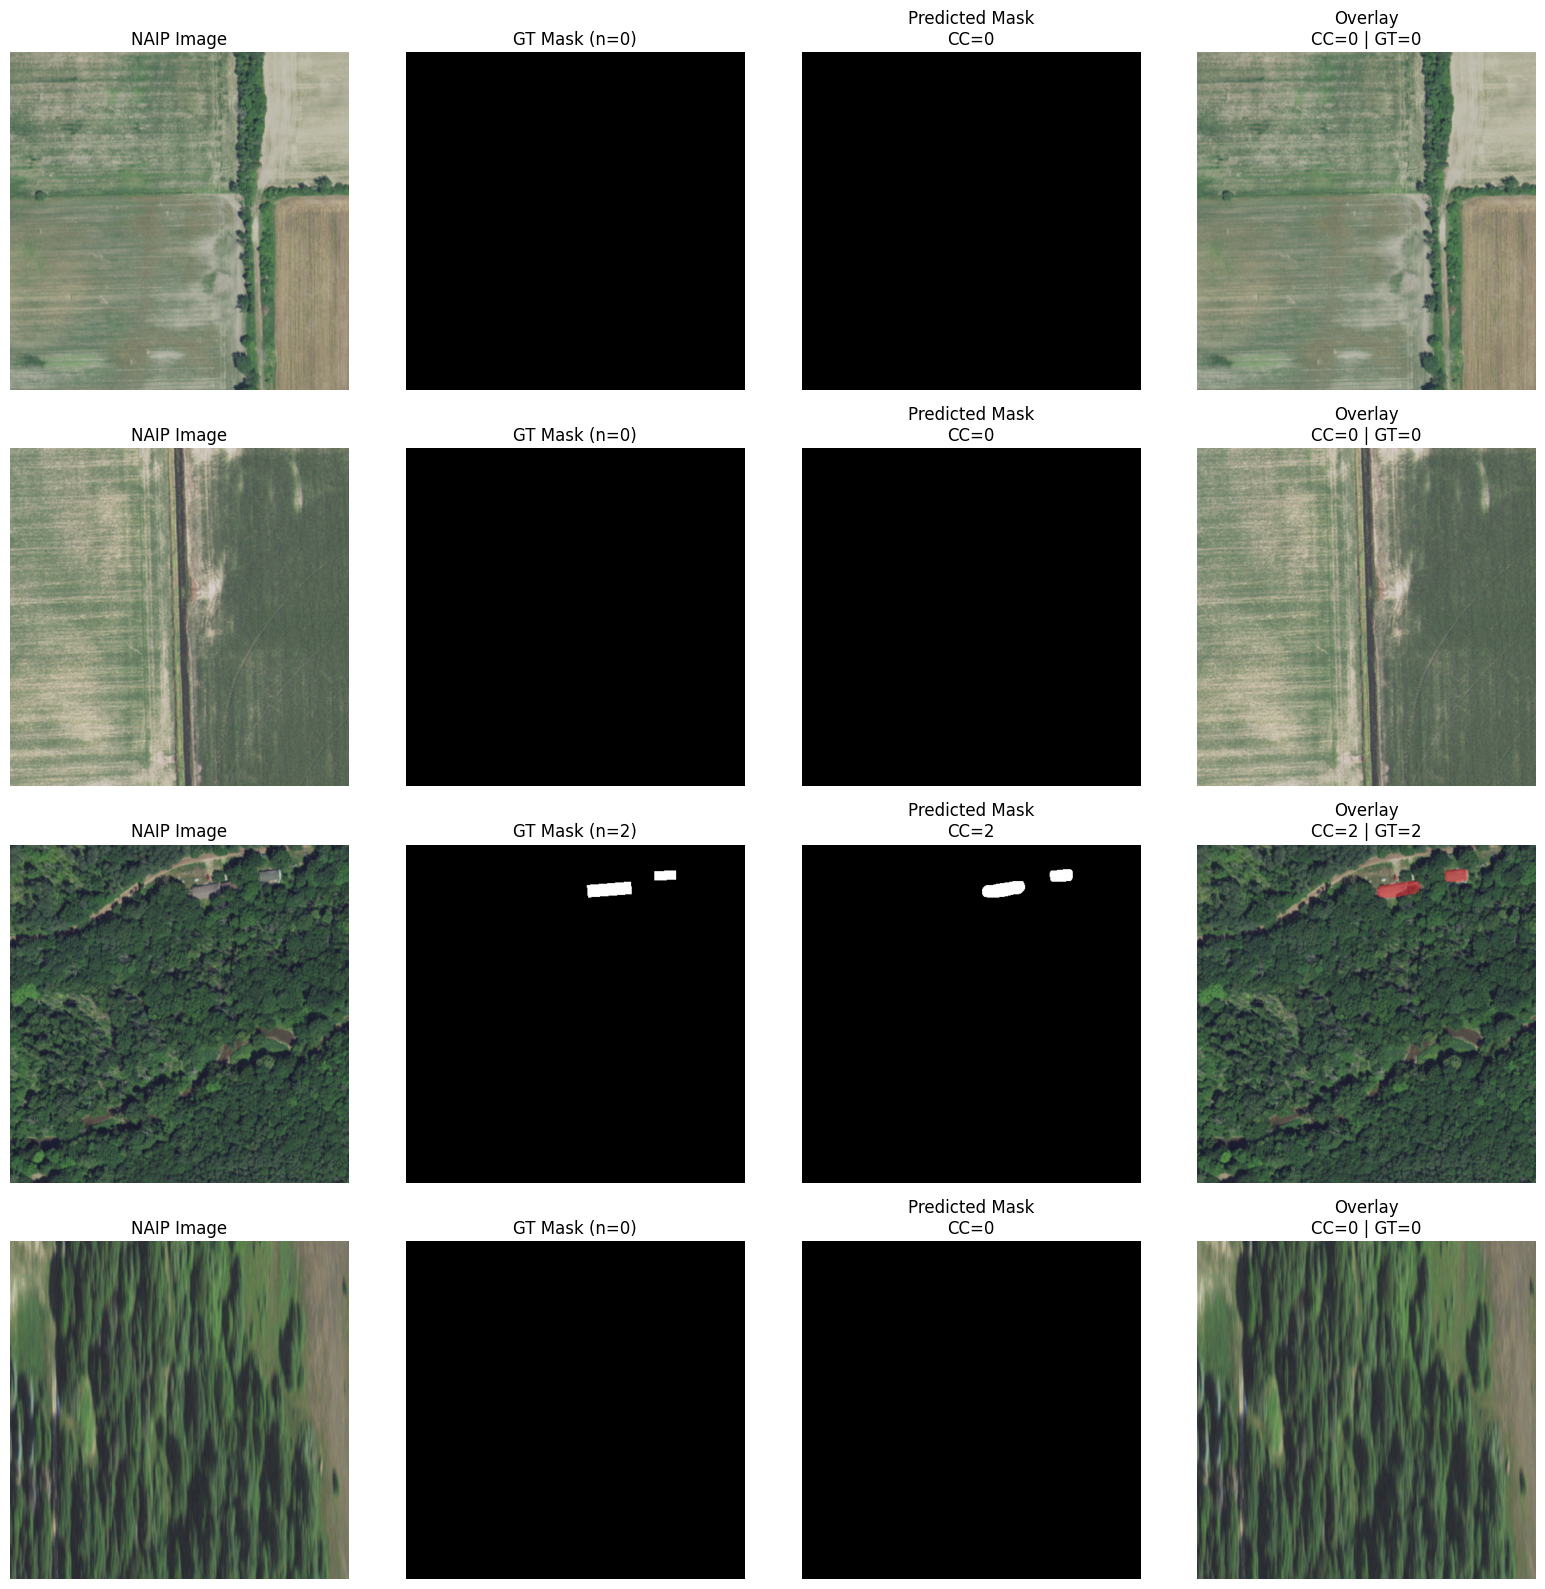

In [ ]:
n_show     = 4
sample_ids = random.sample(val_ids, n_show)
fig, axes  = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))

seg_eval.eval()

for i, tid in enumerate(sample_ids):
    img_np  = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
    mask_np = np.array(Image.open(f'{TILE_MASK_DIR}/{tid}.png').convert('L'))
    gt_cnt  = int(fp_count_map.get(tid, 0))

    aug   = val_aug(image=img_np, mask=(mask_np > 127).astype(np.float32))
    img_t = aug['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        seg_logit = seg_eval(img_t)

    seg_mask = (torch.sigmoid(seg_logit[0, 0]) > THRESHOLD).cpu().numpy()
    labeled  = measure.label(seg_mask)
    cc_cnt   = sum(1 for r in measure.regionprops(labeled) if r.area >= MIN_AREA)

    overlay  = img_np.copy()
    overlay[seg_mask] = (overlay[seg_mask] * 0.5 + np.array([255, 50, 50]) * 0.5).astype(np.uint8)

    axes[i][0].imshow(img_np);                     axes[i][0].set_title('NAIP Image')
    axes[i][1].imshow(mask_np > 127, cmap='gray'); axes[i][1].set_title(f'GT Mask (n={gt_cnt})')
    axes[i][2].imshow(seg_mask, cmap='gray');       axes[i][2].set_title(f'Predicted Mask\nCC={cc_cnt}')
    axes[i][3].imshow(overlay);                     axes[i][3].set_title(f'Overlay\nCC={cc_cnt} | GT={gt_cnt}')
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_c_qualitative.png', dpi=120)
plt.show()

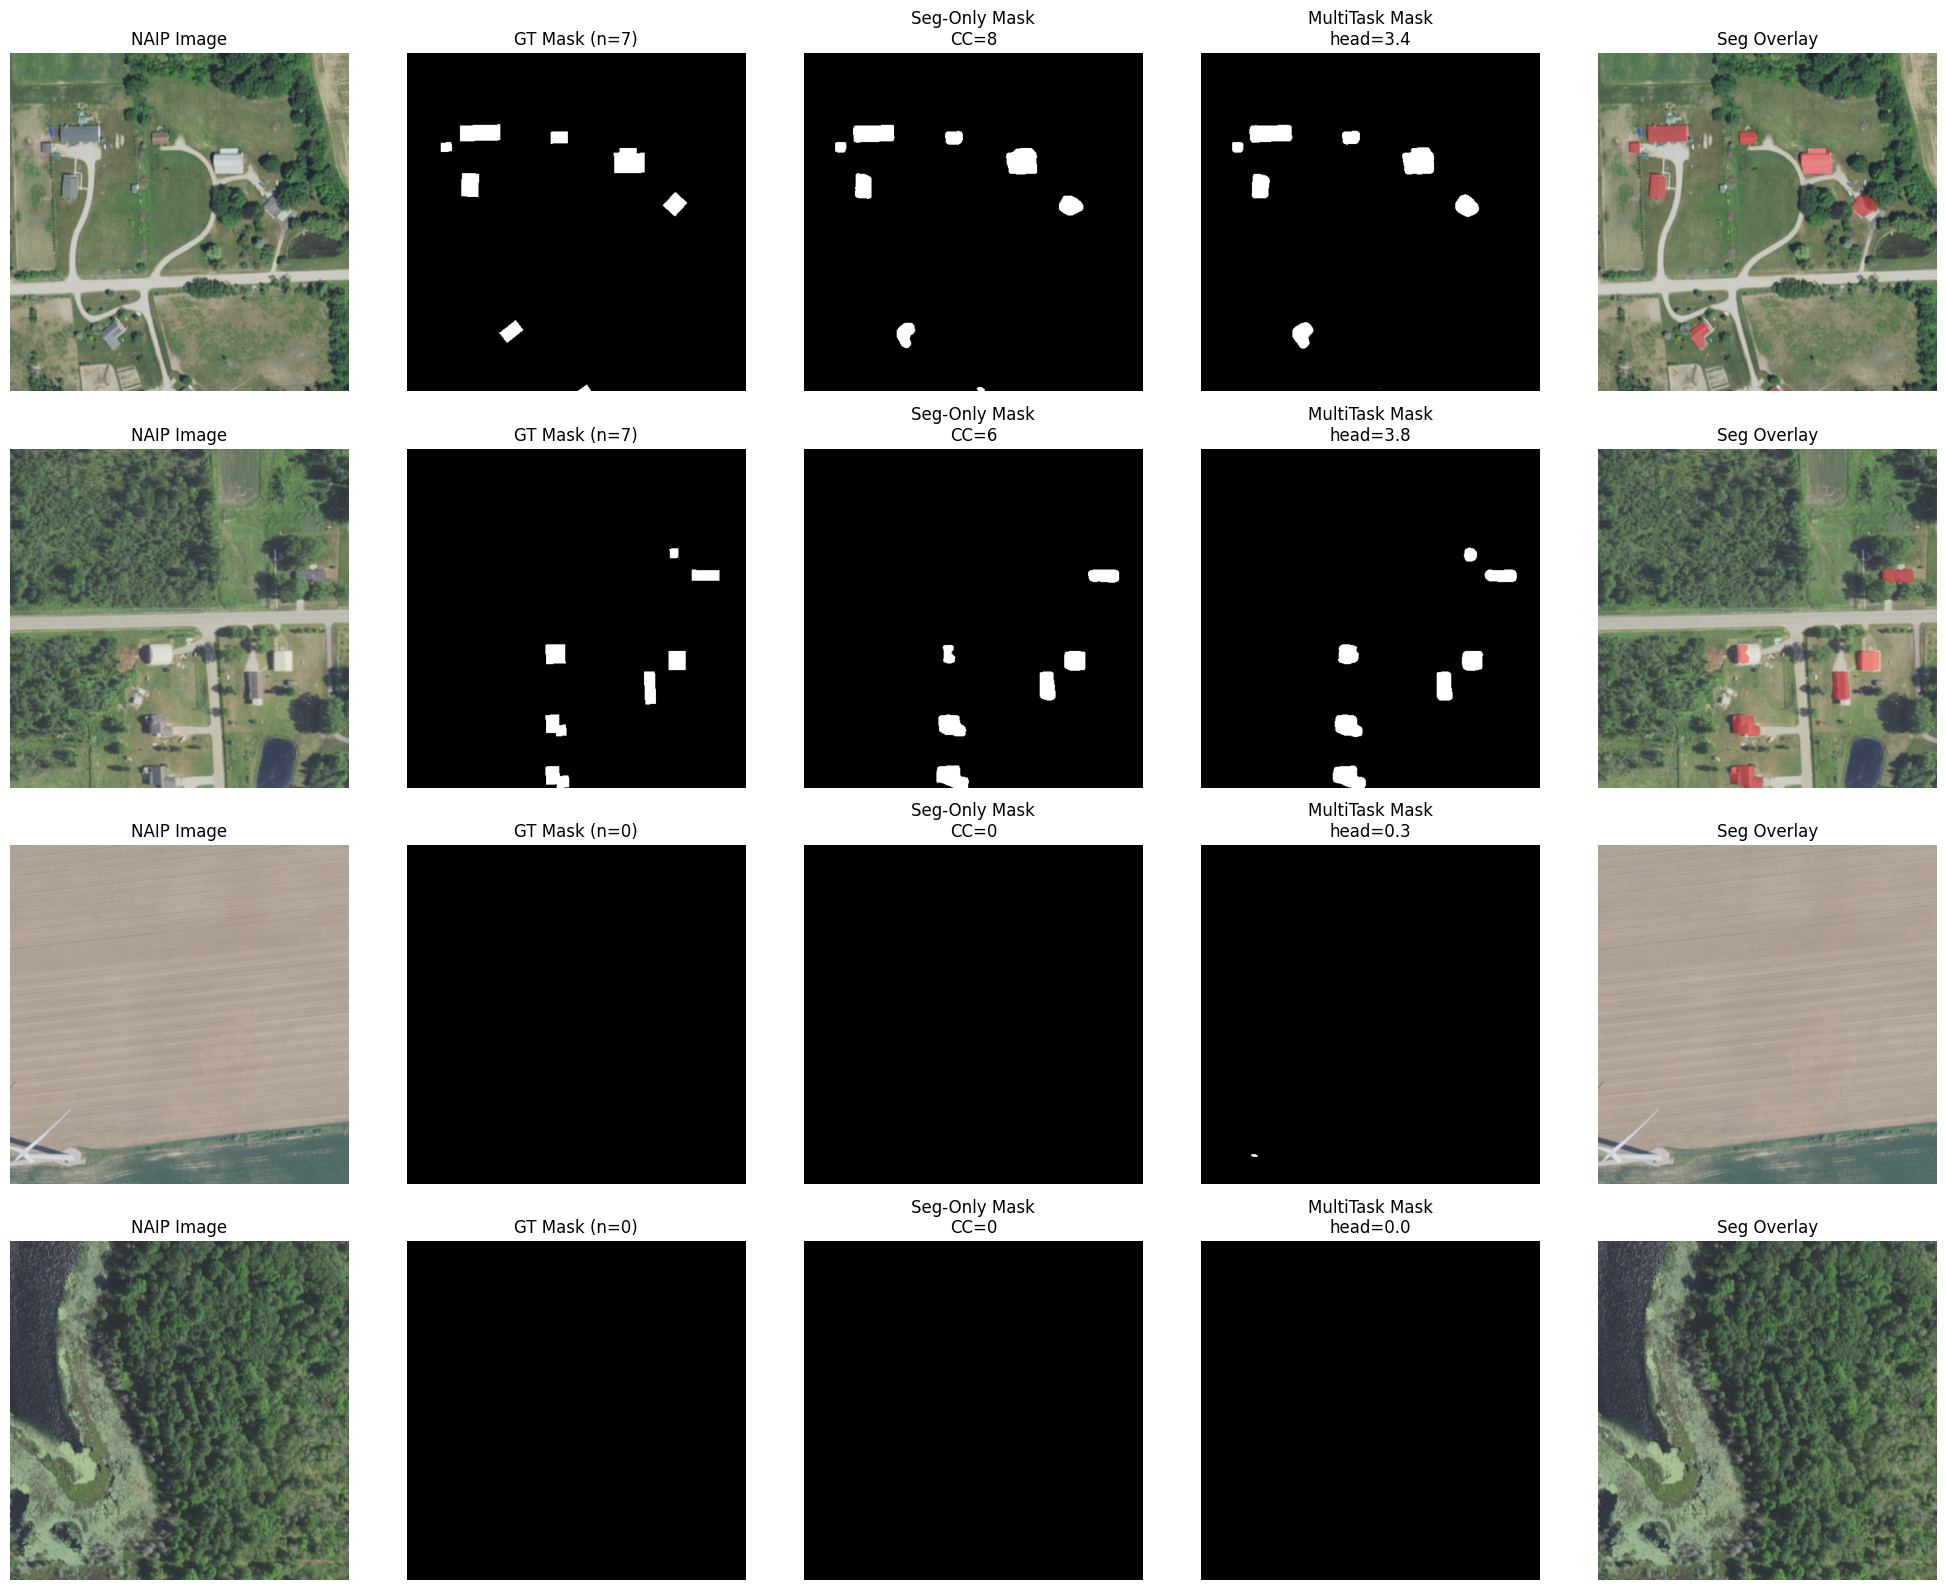

In [ ]:
n_show     = 4
sample_ids = random.sample(val_ids, n_show)
fig, axes  = plt.subplots(n_show, 5, figsize=(20, 4 * n_show))

seg_eval.eval(); mt_eval.eval()

for i, tid in enumerate(sample_ids):
    img_np  = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
    mask_np = np.array(Image.open(f'{TILE_MASK_DIR}/{tid}.png').convert('L'))
    gt_cnt  = int(fp_count_map.get(tid, 0))

    aug   = val_aug(image=img_np, mask=(mask_np > 127).astype(np.float32))
    img_t = aug['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        seg_logit              = seg_eval(img_t)
        seg_logit_mt, cnt_pred = mt_eval(img_t)

    seg_mask = (torch.sigmoid(seg_logit[0, 0])    > THRESHOLD).cpu().numpy()
    mt_mask  = (torch.sigmoid(seg_logit_mt[0, 0]) > THRESHOLD).cpu().numpy()
    labeled  = measure.label(seg_mask)
    cc_cnt   = sum(1 for r in measure.regionprops(labeled) if r.area >= MIN_AREA)
    mt_cnt   = float(torch.expm1(cnt_pred[0].clamp(min=0)).cpu())

    overlay  = img_np.copy()
    overlay[seg_mask] = (overlay[seg_mask] * 0.5 + np.array([255, 50, 50]) * 0.5).astype(np.uint8)

    axes[i][0].imshow(img_np);                     axes[i][0].set_title('NAIP Image')
    axes[i][1].imshow(mask_np > 127, cmap='gray'); axes[i][1].set_title(f'GT Mask (n={gt_cnt})')
    axes[i][2].imshow(seg_mask, cmap='gray');       axes[i][2].set_title(f'Seg-Only Mask\nCC={cc_cnt}')
    axes[i][3].imshow(mt_mask,  cmap='gray');       axes[i][3].set_title(f'MultiTask Mask\nhead={mt_cnt:.1f}')
    axes[i][4].imshow(overlay);                     axes[i][4].set_title('Seg Overlay')
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_c_qualitative.png', dpi=120)
plt.show()

---
# Part D — Summary Visualizations

## D-1. Training History Comparison

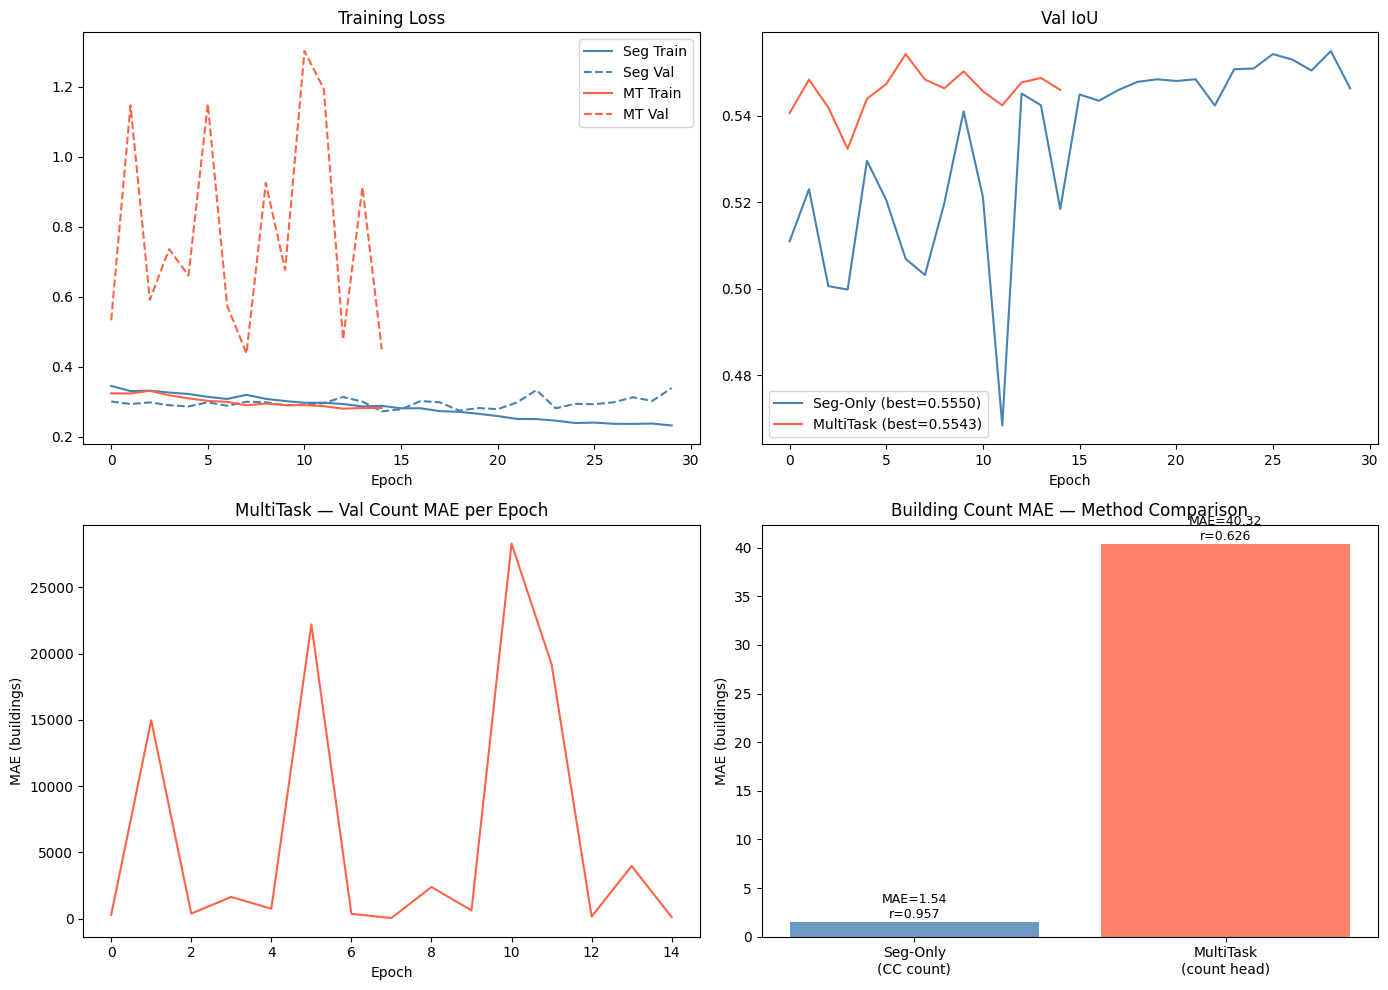

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0][0].plot(hist_seg['train_loss'], label='Seg Train',  color='steelblue')
axes[0][0].plot(hist_seg['val_loss'],   label='Seg Val',    color='steelblue', linestyle='--')
axes[0][0].plot(hist_mt['train_loss'],  label='MT Train',   color='tomato')
axes[0][0].plot(hist_mt['val_loss'],    label='MT Val',     color='tomato',    linestyle='--')
axes[0][0].set_title('Training Loss'); axes[0][0].set_xlabel('Epoch'); axes[0][0].legend()

# IoU
axes[0][1].plot(hist_seg['val_iou'], label=f'Seg-Only (best={best_iou_seg:.4f})', color='steelblue')
axes[0][1].plot(hist_mt['val_iou'],  label=f'MultiTask (best={best_iou_mt:.4f})', color='tomato')
axes[0][1].set_title('Val IoU'); axes[0][1].set_xlabel('Epoch'); axes[0][1].legend()

# MAE over epochs
axes[1][0].plot(hist_mt['val_mae'], color='tomato')
axes[1][0].set_title('MultiTask — Val Count MAE per Epoch')
axes[1][0].set_xlabel('Epoch'); axes[1][0].set_ylabel('MAE (buildings)')

# Bar chart: MAE comparison
methods = ['Seg-Only\n(CC count)', 'MultiTask\n(count head)']
colors  = ['steelblue', 'tomato']
bars    = axes[1][1].bar(methods, [mae_cc, mae_mt], color=colors, alpha=0.8)
axes[1][1].set_title('Building Count MAE — Method Comparison')
axes[1][1].set_ylabel('MAE (buildings)')
for bar, mae, corr in zip(bars, [mae_cc, mae_mt], [corr_cc, corr_mt]):
    axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'MAE={mae:.2f}\nr={corr:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part_d_summary.png', dpi=150)
plt.show()

## D-2. Best Model Summary Table

In [ ]:
summary = pd.DataFrame([
    {'Model': 'Seg-Only U-Net',  'Best Val IoU': round(best_iou_seg, 4),
     'Count MAE': round(mae_cc, 2), 'Pearson r': round(corr_cc, 4),
     'Count method': 'CC (connected components)', 'Checkpoint': ckpt_seg},
    {'Model': 'MultiTask U-Net', 'Best Val IoU': round(best_iou_mt, 4),
     'Count MAE': round(mae_mt, 2), 'Pearson r': round(corr_mt, 4),
     'Count method': 'Count head (log1p)', 'Checkpoint': ckpt_mt},
])
print(summary.to_string(index=False))
print(f'\nBest by MAE        : {"MultiTask" if mae_mt < mae_cc else "Seg-Only (CC)"}')
print(f'Best by correlation: {"MultiTask" if corr_mt > corr_cc else "Seg-Only (CC)"}')

          Model  Best Val IoU  Count MAE  Pearson r              Count method                              Checkpoint
 Seg-Only U-Net        0.5550       1.54     0.9568 CC (connected components)           unet_seg_best_full_curated.pt
MultiTask U-Net        0.5543      40.32     0.6264        Count head (log1p) unet_multitask_best_mae_full_curated.pt

Best by MAE        : Seg-Only (CC)
Best by correlation: Seg-Only (CC)


## D-3. Best Model Selection

In [ ]:
# ── Best Model Selection ─────────────────────────────────────────────────
print('=' * 54)
print('  BEST MODEL SELECTION')
print('=' * 54)

# Score: lower MAE = better, higher corr = better
# Normalize both metrics into a single score (rank-based)
seg_score = (1 if mae_cc <= mae_mt else 0) + (1 if corr_cc >= corr_mt else 0)
mt_score  = (1 if mae_mt <= mae_cc else 0) + (1 if corr_mt >= corr_cc else 0)

print(f'  Seg-Only  U-Net | IoU={best_iou_seg:.4f} | MAE={mae_cc:.2f} | r={corr_cc:.4f}')
print(f'  MultiTask U-Net | IoU={best_iou_mt:.4f} | MAE={mae_mt:.2f} | r={corr_mt:.4f}')
print()

if mt_score > seg_score:
    best_model_name = 'MultiTask U-Net'
    best_ckpt       = ckpt_mt
    best_iou_final  = best_iou_mt
    best_mae_final  = mae_mt
    best_corr_final = corr_mt
elif seg_score > mt_score:
    best_model_name = 'Seg-Only U-Net'
    best_ckpt       = ckpt_seg
    best_iou_final  = best_iou_seg
    best_mae_final  = mae_cc
    best_corr_final = corr_cc
else:
    # Tiebreak: MAE (primary goal is count accuracy)
    if mae_mt <= mae_cc:
        best_model_name = 'MultiTask U-Net'
        best_ckpt       = ckpt_mt
        best_iou_final  = best_iou_mt
        best_mae_final  = mae_mt
        best_corr_final = corr_mt
    else:
        best_model_name = 'Seg-Only U-Net'
        best_ckpt       = ckpt_seg
        best_iou_final  = best_iou_seg
        best_mae_final  = mae_cc
        best_corr_final = corr_cc

print(f'  >> BEST MODEL  : {best_model_name}')
print(f'  >> Checkpoint  : {best_ckpt}')
print(f'  >> Val IoU     : {best_iou_final:.4f}')
print(f'  >> Count MAE   : {best_mae_final:.2f}')
print(f'  >> Pearson r   : {best_corr_final:.4f}')
print('=' * 54)
print()
print('  -> This checkpoint will be used for Phase 4 tuning and Phase 5 inference.')

  BEST MODEL SELECTION
  Seg-Only  U-Net | IoU=0.5550 | MAE=1.54 | r=0.9568
  MultiTask U-Net | IoU=0.5543 | MAE=40.32 | r=0.6264

  >> BEST MODEL  : Seg-Only U-Net
  >> Checkpoint  : unet_seg_best_full_curated.pt
  >> Val IoU     : 0.5550
  >> Count MAE   : 1.54
  >> Pearson r   : 0.9568

  -> This checkpoint will be used for Phase 4 tuning and Phase 5 inference.


---
# Part E — Experiment Log

In [ ]:
log_rows = [
    {'phase': 'phase3_seg_full_curated', 'model': 'seg-only U-Net',
     'sampling': 'full_curated', 'loss': f'{BCE_W}BCE+{DICE_W}Dice',
     'threshold': THRESHOLD, 'min_area': MIN_AREA,
     'train_tiles': len(train_ids), 'val_tiles': len(val_ids),
     'best_val_iou': round(best_iou_seg, 4), 'final_val_mae': None,
     'cc_mae': round(mae_cc, 2), 'cc_corr': round(corr_cc, 4),
     'mt_mae': None, 'mt_corr': None, 'checkpoint': ckpt_seg},
    {'phase': 'phase3_multitask_full_curated', 'model': 'MultiTaskUNet',
     'sampling': 'full_curated', 'loss': f'{BCE_W}BCE+{DICE_W}Dice seg + {COUNT_W}MSE cnt',
     'threshold': THRESHOLD, 'min_area': MIN_AREA,
     'train_tiles': len(train_ids), 'val_tiles': len(val_ids),
     'best_val_iou': round(best_iou_mt, 4), 'final_val_mae': round(best_mae_mt, 2),
     'cc_mae': None, 'cc_corr': None,
     'mt_mae': round(mae_mt, 2), 'mt_corr': round(corr_mt, 4), 'checkpoint': ckpt_mt},
]

log_path = f'{BASE_DIR}/results/experiment_log.csv'
os.makedirs(f'{BASE_DIR}/results', exist_ok=True)
new_df = pd.DataFrame(log_rows)
if os.path.exists(log_path):
    new_df = pd.concat([pd.read_csv(log_path), new_df], ignore_index=True)
new_df.to_csv(log_path, index=False)

print('[Experiment Log — Phase 3 Summary]')
print(new_df.tail(2).to_string(index=False))

[Experiment Log — Phase 3 Summary]
                        phase          model     sampling                            loss  threshold  min_area  train_tiles  val_tiles  best_val_iou  final_val_mae  cc_mae  cc_corr  mt_mae  mt_corr                              checkpoint
      phase3_seg_full_curated seg-only U-Net full_curated                  0.5BCE+0.5Dice        0.5        50         5969       1493        0.5550            NaN    1.54   0.9568     NaN      NaN           unet_seg_best_full_curated.pt
phase3_multitask_full_curated  MultiTaskUNet full_curated 0.5BCE+0.5Dice seg + 0.5MSE cnt        0.5        50         5969       1493        0.5543          40.24     NaN      NaN   40.32   0.6264 unet_multitask_best_mae_full_curated.pt
